<a href="https://colab.research.google.com/github/musowjanya/Datascience-Project/blob/main/L3T2_Custimer_preference_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Dataset .csv")

print(df.columns)
print(df.head())

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chin

In [3]:
# Remove missing cuisines
df = df.dropna(subset=["Cuisines"])

# Split multiple cuisines
df["Cuisines"] = df["Cuisines"].str.split(", ")

# Explode so each cuisine gets its own row
df_exploded = df.explode("Cuisines")


Average Rating by Cuisine:
 Cuisines
Sunda         4.900000
B�_rek        4.700000
Taiwanese     4.650000
Ramen         4.500000
Dim Sum       4.466667
Hawaiian      4.412500
Bubble Tea    4.400000
D�_ner        4.400000
Curry         4.400000
Kebab         4.380000
Name: Aggregate rating, dtype: float64


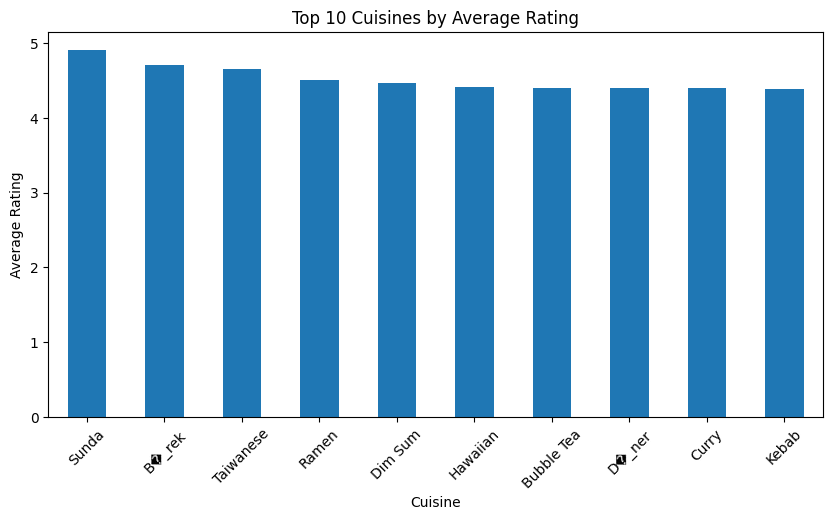

In [4]:
cuisine_rating = df_exploded.groupby("Cuisines")["Aggregate rating"].mean().sort_values(ascending=False)

print("\nAverage Rating by Cuisine:\n", cuisine_rating.head(10))

# Plot top rated cuisines
plt.figure(figsize=(10,5))
cuisine_rating.head(10).plot(kind='bar')
plt.title("Top 10 Cuisines by Average Rating")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()


Most Popular Cuisines (by Votes):
 Cuisines
North Indian    595981
Chinese         364351
Italian         329265
Continental     288255
Fast Food       184058
American        183117
Cafe            177568
Mughlai         151946
Desserts        105889
Asian           104303
Name: Votes, dtype: int64


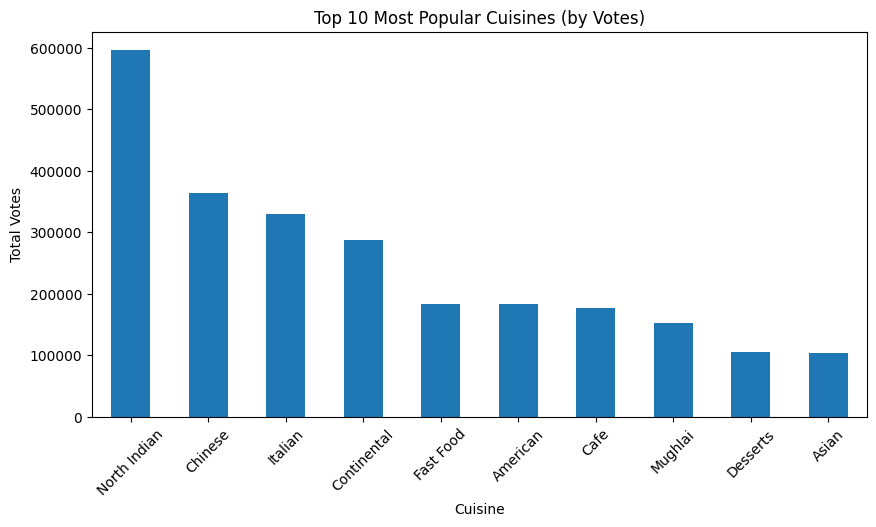

In [5]:
cuisine_votes = df_exploded.groupby("Cuisines")["Votes"].sum().sort_values(ascending=False)

print("\nMost Popular Cuisines (by Votes):\n", cuisine_votes.head(10))

# Plot
plt.figure(figsize=(10,5))
cuisine_votes.head(10).plot(kind='bar')
plt.title("Top 10 Most Popular Cuisines (by Votes)")
plt.xlabel("Cuisine")
plt.ylabel("Total Votes")
plt.xticks(rotation=45)
plt.show()

In [6]:
# Filter cuisines with enough data (avoid bias)
cuisine_counts = df_exploded["Cuisines"].value_counts()

# Keep cuisines with at least 20 restaurants
valid_cuisines = cuisine_counts[cuisine_counts >= 20].index

filtered_df = df_exploded[df_exploded["Cuisines"].isin(valid_cuisines)]

high_rated_cuisines = filtered_df.groupby("Cuisines")["Aggregate rating"].mean().sort_values(ascending=False)

print("\nCuisines with Consistently High Ratings:\n", high_rated_cuisines.head(10))


Cuisines with Consistently High Ratings:
 Cuisines
International    4.247619
Southern         4.129167
Vegetarian       4.073913
Sandwich         4.066038
Grill            4.057143
Steak            3.985484
Sushi            3.973333
Goan             3.970000
Breakfast        3.965854
Mediterranean    3.948214
Name: Aggregate rating, dtype: float64


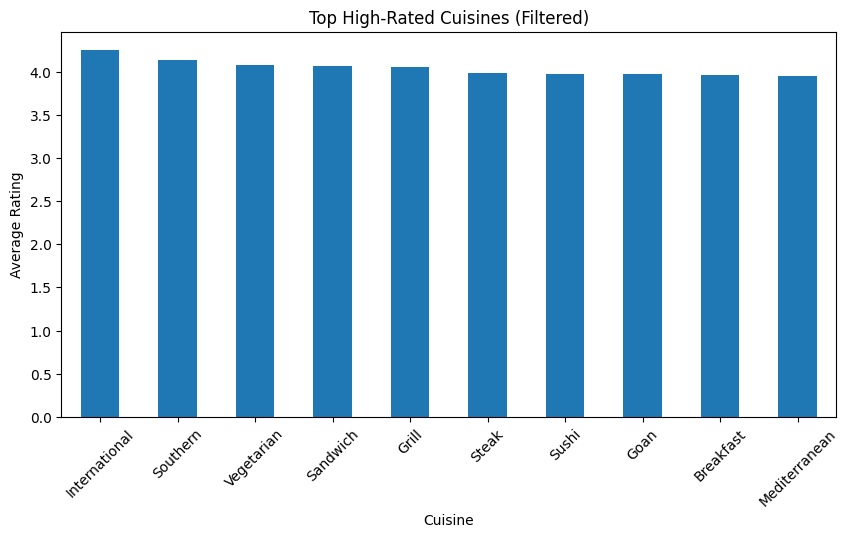

In [7]:
# Plot
plt.figure(figsize=(10,5))
high_rated_cuisines.head(10).plot(kind='bar')
plt.title("Top High-Rated Cuisines (Filtered)")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

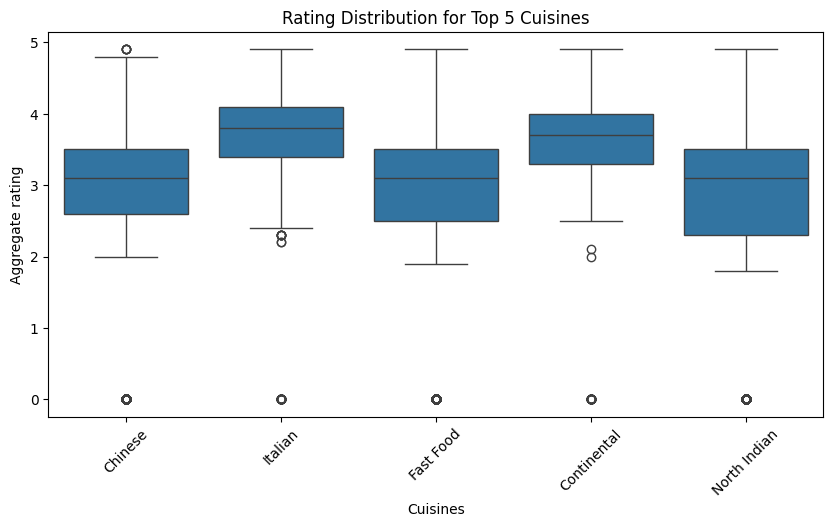

In [8]:
# Top 5 cuisines for comparison
top5 = cuisine_votes.head(5).index

subset = df_exploded[df_exploded["Cuisines"].isin(top5)]

plt.figure(figsize=(10,5))
sns.boxplot(data=subset, x="Cuisines", y="Aggregate rating")
plt.title("Rating Distribution for Top 5 Cuisines")
plt.xticks(rotation=45)
plt.show()